# Protein-Protein Interaction Network Analysis for Endometriosis

Social Network Analysis, MIMUW 2026

Agata Kopeć, 469385

## Research question

Which set of k proteins, when blocked simultaneously, most effectively limits the propagation of the disease signal in the endometriosis PPI network? Does the optimal set depend on the chosen measure?

## Methodology

1. Construct the PPI network from DisGeNET, with genes associated with endometriosis under UMLS concept C0014175, and from STRING, with protein interactions among them.
2. Generate three null models as a baseline for randomness: Erdős-Rényi, Barabási-Albert, and configuration model.
3. Apply group centrality algorithms and diffusion models to identify the optimal set across k ∈ {1, 2, 5, 10, 20, 50, 100, 150, 200, 250, 300}.


## Setup

Imports and constants used throughout the notebook. STRING parameters follow the project plan: human proteins under taxon 9606, and confidence at least 0.4. K_VALUES defines the scan range for the blocking analysis.

In [1]:
from pathlib import Path
import heapq
import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import requests

DATA_DIR = Path("data")
RESULTS_DIR = Path("results")
FIGURES_DIR = RESULTS_DIR / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

DISGENET_FILE = DATA_DIR / "search_result_C0014175.tsv"
STRING_CACHE = RESULTS_DIR / "string_network.tsv"

STRING_SPECIES = 9606
STRING_REQUIRED_SCORE = 400
STRING_CALLER = "mimuw-sla-endo"
STRING_ADD_NODES = 300

K_VALUES = [1, 2, 5, 10, 20, 50, 100, 150, 200, 250, 300]
RANDOM_SEED = 42


## Data loading

Nodes are proteins encoded by genes from DisGeNET that are associated with endometriosis, under UMLS concept C0014175. Edges are protein-protein interactions retrieved from STRING.

The DisGeNET gene list, exported from the DisGeNET web search with the score > 0.25 filter already applied, is shipped in `data/search_result_C0014175.tsv` for reproducibility; all rows are kept as is. STRING interactions are fetched on first run and cached locally to `results/string_network.tsv`; rerunning reuses the cache.

In [2]:
disgenet_df = pd.read_csv(DISGENET_FILE, sep="\t").dropna(subset=["Gene"]).drop_duplicates("Gene")
genes = disgenet_df["Gene"].tolist()
print(f"Loaded {len(genes)} genes from DisGeNET")

Loaded 166 genes from DisGeNET


In [3]:
if not STRING_CACHE.exists():
    response = requests.post(
        "https://string-db.org/api/tsv/network",
        data={
            "identifiers": "\r".join(genes),
            "species": STRING_SPECIES,
            "required_score": STRING_REQUIRED_SCORE,
            "caller_identity": STRING_CALLER,
            "add_nodes": STRING_ADD_NODES,
        },
        timeout=60,
    )
    response.raise_for_status()
    STRING_CACHE.write_text(response.text)

string_df = pd.read_csv(STRING_CACHE, sep="\t")
print(f"Retrieved {len(string_df)} interactions from STRING")

Retrieved 21095 interactions from STRING


In [4]:
G_ppi = nx.from_pandas_edgelist(
    string_df, source="preferredName_A", target="preferredName_B"
)
print(f"Nodes: {G_ppi.number_of_nodes()}")
print(f"Edges: {G_ppi.number_of_edges()}")
print(f"Connected components: {nx.number_connected_components(G_ppi)}")

Nodes: 454
Edges: 21095
Connected components: 1


## Random null models

To verify that observed effects stem from the specific topology of the PPI network rather than randomness, we generate three null models, each matched to the empirical graph on the number of nodes.

- Erdős-Rényi: independent edges placed with probability equal to the PPI density. Pure-randomness baseline.
- Barabási-Albert: preferential attachment with parameter m chosen so the total edge count roughly matches the PPI; tests whether scale-free structure alone explains what we see.
- Configuration model: random rewiring that preserves the empirical degree sequence; the strictest null, isolating topological effects from those of the degree distribution alone.

All four networks are stored in a single dictionary so downstream analysis runs uniformly across them.

In [5]:
n_ppi = G_ppi.number_of_nodes()
m_ppi = G_ppi.number_of_edges()
density_ppi = nx.density(G_ppi)
m_ba = max(1, round((n_ppi - (n_ppi**2 - 4 * m_ppi) ** 0.5) / 2))

G_er = nx.gnp_random_graph(n_ppi, density_ppi, seed=RANDOM_SEED)
G_ba = nx.barabasi_albert_graph(n_ppi, m_ba, seed=RANDOM_SEED)
# Edge swaps preserve the empirical degree sequence exactly, with no parallel-edge collapse.
G_cm = G_ppi.copy()
nx.double_edge_swap(G_cm, nswap=10 * m_ppi, max_tries=100 * m_ppi, seed=RANDOM_SEED)

networks = {"PPI": G_ppi, "ER": G_er, "BA": G_ba, "CM": G_cm}
for name, G in networks.items():
    print(f"{name}: V={G.number_of_nodes()}, E={G.number_of_edges()}")

PPI: V=454, E=21095
ER: V=454, E=21253
BA: V=454, E=21253
CM: V=454, E=21095


## Network statistics and degree distribution

We compare the four networks on density, average degree, clustering, average shortest path length, and degree assortativity. These give a first sense of how much the PPI graph differs from each null model.

The log-log degree distribution in Figure 1 is more diagnostic: heavy tails are characteristic of biological networks, and overlapping PPI with the three nulls reveals how much of the empirical structure is driven by the degree distribution alone. ER produces a narrow Poisson-like peak by construction, BA traces a power law by construction, and CM coincides with PPI by construction since it preserves the empirical degree sequence exactly. The 2x2 panel pairs PPI with CM in the top row so that their identical empirical curves sit directly above each other; ER and BA occupy the bottom row.

In [6]:
stats = []
for name, G in networks.items():
    if nx.is_connected(G):
        avg_path = nx.average_shortest_path_length(G)
    else:
        largest = max(nx.connected_components(G), key=len)
        avg_path = nx.average_shortest_path_length(G.subgraph(largest))
    stats.append({
        "Network": name,
        "|V|": G.number_of_nodes(),
        "|E|": G.number_of_edges(),
        "Density": round(nx.density(G), 3),
        "Avg degree": round(2 * G.number_of_edges() / G.number_of_nodes(), 1),
        "Clustering": round(nx.average_clustering(G), 3),
        "Avg path length": round(avg_path, 2),
        "Assortativity": round(nx.degree_assortativity_coefficient(G), 3),
    })
stats_df = pd.DataFrame(stats).set_index("Network")
stats_df

,|V|,|E|,Density,Avg degree,Clustering,Avg path length,Assortativity
Network,,,,,,,
PPI,454,21095,0.205,92.9,0.637,1.94,0.052
ER,454,21253,0.207,93.6,0.206,1.79,-0.005
BA,454,21253,0.207,93.6,0.298,1.79,-0.019
CM,454,21095,0.205,92.9,0.512,1.84,-0.181


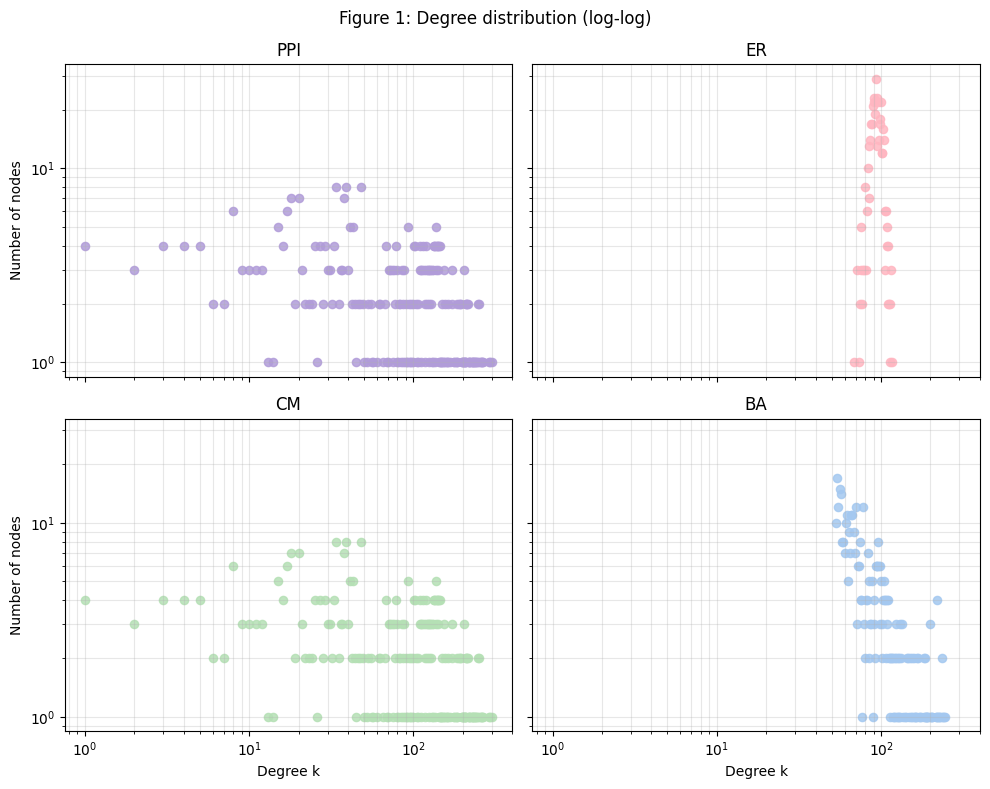

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(10, 8), sharex=True, sharey=True)
colors = {"PPI": "#B19CD9", "ER": "#FFB6C1", "BA": "#A4C8F0", "CM": "#B5E0B5"}
order = ["PPI", "ER", "CM", "BA"]
for ax, name in zip(axes.flat, order):
    G = networks[name]
    ks, counts = np.unique([d for _, d in G.degree()], return_counts=True)
    mask = ks > 0
    ax.scatter(ks[mask], counts[mask], color=colors[name], alpha=0.85, s=35, marker="o")
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_title(name)
    ax.grid(True, which="both", alpha=0.3)
for ax in axes[-1, :]:
    ax.set_xlabel("Degree k")
for ax in axes[:, 0]:
    ax.set_ylabel("Number of nodes")
fig.suptitle("Figure 1: Degree distribution (log-log)")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "fig1_degree_distribution.pdf", bbox_inches="tight")
plt.show()

## Conclusions from network statistics

PPI differs from all three nulls on two descriptors that matter for the analysis.

Clustering is much higher in PPI than in any null:
- PPI 0.637
- ER 0.206
- BA 0.298
- CM 0.512

PPI proteins form dense modular groups, a signature of biological function. CM gets closest because preserving the degree sequence already induces some local clustering, yet PPI still exceeds CM by roughly 25 percent, indicating structure beyond what degrees alone explain.

Assortativity is positive only for PPI, at 0.052. ER and BA are near zero; CM is strongly disassortative at -0.181, a structural cutoff effect typical of degree-randomized dense graphs. Positive assortativity in PPI means high-degree hubs tend to interact with other hubs, forming a connected core.

Average shortest path length is similar across all networks, between 1.8 and 1.9, and does not discriminate at this density.

Figure 1 confirms the expected shapes: PPI and CM share an identical heavy-tailed degree distribution by construction, BA traces a power law with a different exponent, and ER produces the narrow Poisson-like peak centered on the mean degree.

## Diffusion models

Group centrality algorithms decide which proteins to block. Diffusion models decide how much that blocking is worth. The two coupled together turn the research question into a quantitative optimization problem: for a candidate blocking set B we simulate the disease signal propagating through the network with the nodes in B removed, then measure how many proteins are ultimately reached. The reduction in reach relative to the unblocked baseline is the spread reduction, and the goal is to find B of fixed size k that maximizes it.

We use two propagation processes from the project plan, chosen so they probe qualitatively different dynamics.

SIR, the Susceptible-Infected-Recovered model. At each discrete time step every infected node attempts to infect each susceptible neighbor with probability β, then recovers with probability γ. Recovered nodes are immune. The simulation terminates when no infected nodes remain, and the spread is reported as the final size of the recovered set. SIR is the canonical compartmental model from epidemiology and captures persistent contagion with multiple attempts per edge.

IC, the Independent Cascade model. A newly activated node receives a single opportunity to activate each of its inactive neighbors with probability p, after which it is exhausted. The spread is the final size of the activated set. IC is the canonical influence-propagation model from social network theory. Pairing it with SIR lets us check whether the optimal blocking set is sensitive to the choice of dynamics, contrasting multi-attempt with recovery against single-shot without recovery.

Three conventions hold across both simulations:
- Seeds are the high-confidence subset of DisGeNET disease genes, those with score >= 0.7, restricted to nodes present in the PPI graph. The top-quartile threshold focuses the signal on entries whose association with endometriosis is supported by the strongest curated evidence, and the resulting seed set is small enough to leave headroom for the blocking experiment: the unblocked spread can range from a modest fraction of the network up to near saturation depending on the dynamics. The full DisGeNET list still defines the graph topology through STRING first-shell expansion; only the high-confidence subset is used as propagation source.
- Blocked nodes are removed from the graph for the duration of the simulation, so they are dropped from the seed set if present and become unreachable as targets.
- Each configuration is averaged over `N_RUNS = 50` Monte Carlo realizations to control stochastic variance. Fifty replicates keep the standard error of the mean below 1% of the network size in the calibrated operating regime, well under the spread differences we expect blocking strategies to produce.

In [8]:
SEED_SCORE_THRESHOLD = 0.7
seed_candidates = disgenet_df.loc[disgenet_df["score"] >= SEED_SCORE_THRESHOLD, "Gene"]
DISEASE_SEEDS = sorted(set(seed_candidates) & set(G_ppi.nodes))
print(f"Diffusion seeds: {len(DISEASE_SEEDS)} genes (score >= {SEED_SCORE_THRESHOLD}) present in PPI graph")

N_RUNS = 50


def _blocked_adjacency(G, blocked):
    """Return adjacency dict and blocked-set with blocked nodes excluded."""
    blocked_set = set(blocked or ())
    adj = {
        n: [v for v in G.neighbors(n) if v not in blocked_set]
        for n in G.nodes
        if n not in blocked_set
    }
    return adj, blocked_set


def simulate_sir(G, seeds, beta, gamma, n_runs=N_RUNS, blocked=None, rng=None):
    """Mean and standard deviation of the final recovered-set size under SIR."""
    rng = rng if rng is not None else np.random.default_rng(RANDOM_SEED)
    adj, blocked_set = _blocked_adjacency(G, blocked)
    seeds_eff = [s for s in seeds if s not in blocked_set]
    sizes = np.empty(n_runs)
    for run in range(n_runs):
        infected = set(seeds_eff)
        recovered = set()
        while infected:
            new_infected = set()
            for u in sorted(infected):
                for v in adj.get(u, ()):
                    if v in infected or v in recovered:
                        continue
                    if rng.random() < beta:
                        new_infected.add(v)
            new_recovered = {u for u in sorted(infected) if rng.random() < gamma}
            recovered |= new_recovered
            infected = (infected | new_infected) - new_recovered
        sizes[run] = len(recovered)
    return float(sizes.mean()), float(sizes.std())


def simulate_ic(G, seeds, p, n_runs=N_RUNS, blocked=None, rng=None):
    """Mean and standard deviation of the final activated-set size under Independent Cascade."""
    rng = rng if rng is not None else np.random.default_rng(RANDOM_SEED)
    adj, blocked_set = _blocked_adjacency(G, blocked)
    seeds_eff = [s for s in seeds if s not in blocked_set]
    sizes = np.empty(n_runs)
    for run in range(n_runs):
        activated = set(seeds_eff)
        frontier = set(seeds_eff)
        while frontier:
            new_frontier = set()
            for u in sorted(frontier):
                for v in adj.get(u, ()):
                    if v in activated:
                        continue
                    if rng.random() < p:
                        new_frontier.add(v)
            activated |= new_frontier
            frontier = new_frontier
        sizes[run] = len(activated)
    return float(sizes.mean()), float(sizes.std())

Diffusion seeds: 23 genes (score >= 0.7) present in PPI graph


## Parameter calibration

Before using the simulators as a measurement instrument we calibrate β, γ, and p on the unblocked PPI graph. The first-shell expansion produces a dense network with mean degree close to 93, so values an order of magnitude smaller than typical sparse-graph defaults are required. Too large and the network saturates immediately, leaving no headroom for blocking to matter. Too small and propagation dies out, so any blocking strategy looks spuriously effective.

We sweep a short grid and select operating points that yield an unblocked spread between roughly 60% and 85% of the network: large enough to leave a meaningful gradient for the blocking experiment, small enough that the dynamics have not collapsed into a trivial regime.

In [9]:
n_nodes = G_ppi.number_of_nodes()
print(f"Network size: {n_nodes} nodes,  unblocked seeds: {len(DISEASE_SEEDS)} [{100 * len(DISEASE_SEEDS) / n_nodes:.0f}% of graph]")
print()
print("SIR sweep:")
for beta, gamma in [(0.005, 0.2), (0.01, 0.2), (0.02, 0.2), (0.05, 0.2)]:
    mean, std = simulate_sir(G_ppi, DISEASE_SEEDS, beta, gamma)
    print(f"  beta={beta:.3f}, gamma={gamma:.2f}  ->  spread {mean:6.1f} +/- {std:4.1f}  [{100 * mean / n_nodes:4.0f}%]")

print()
print("IC sweep:")
for p in [0.005, 0.01, 0.02, 0.05]:
    mean, std = simulate_ic(G_ppi, DISEASE_SEEDS, p)
    print(f"  p={p:.3f}                ->  spread {mean:6.1f} +/- {std:4.1f}  [{100 * mean / n_nodes:4.0f}%]")

SIR_BETA = 0.005
SIR_GAMMA = 0.2
IC_P = 0.02

Network size: 454 nodes,  unblocked seeds: 23 [5% of graph]

SIR sweep:


  beta=0.005, gamma=0.20  ->  spread  318.7 +/- 11.9  [  70%]


  beta=0.010, gamma=0.20  ->  spread  382.3 +/-  6.9  [  84%]


  beta=0.020, gamma=0.20  ->  spread  418.6 +/-  4.7  [  92%]


  beta=0.050, gamma=0.20  ->  spread  439.5 +/-  2.9  [  97%]

IC sweep:
  p=0.005                ->  spread   59.9 +/- 12.0  [  13%]
  p=0.010                ->  spread  170.5 +/- 20.6  [  38%]


  p=0.020                ->  spread  294.7 +/- 10.3  [  65%]
  p=0.050                ->  spread  386.0 +/-  6.9  [  85%]


## Operating points

The sweep selects β = 0.005, γ = 0.2 for SIR and p = 0.02 for IC. Both produce an unblocked spread near the middle of the target band, around 70% and 65% of the network, with coefficient of variation below 4% across the 50 Monte Carlo replicates. This leaves roughly 60 percentage points of headroom between the unblocked baseline and the 5% seed floor, ample room for blocking strategies to produce a measurable and statistically resolvable gradient.

For IC, the next grid point below, p = 0.01, sits near the percolation threshold with run-to-run variance roughly four times higher; choosing p = 0.02 places the measurement in a stable regime. For SIR, the dense network with mean degree close to 93 forces β an order of magnitude smaller than typical sparse-graph defaults, so the chosen value sits at the low end of the swept range.

## Group centrality and the blocking set

A blocking set is a fixed-size subset of proteins removed from the network as a candidate therapeutic intervention. The research question asks which subset of size k minimizes propagation of the disease signal. We compare three algorithmic strategies that span the reasonable choices for this problem.

Greedy group degree. At each step add the node whose closed neighborhood adds the most previously uncovered nodes. The objective is purely structural and treats blocking value as the number of distinct proteins the blocked set can directly reach. This is the standard maximum-coverage formulation, and greedy selection achieves a 1 - 1/e approximation factor of the optimal coverage objective.

Greedy iterative betweenness. At each step compute node betweenness on the current graph, take the maximum, remove it, repeat. The objective tracks shortest-path routing. This recipe is the standard attack-tolerance procedure in network robustness literature and identifies proteins whose removal most fragments the graph.

CELF, the Cost-Effective Lazy Forward algorithm. At each step add the node whose addition to the blocked set most reduces simulated diffusion spread, using a lazy priority queue that recomputes marginal gains only when they become stale. CELF is the only one of the three that consults the diffusion model directly and serves as the diffusion-aware reference against which to judge whether topology-only heuristics suffice. Spread reduction by node blocking is submodular under Independent Cascade; under SIR it is treated as approximately so for the regimes used here. CELF inherits the standard lazy-greedy guarantee on the IC side and remains a principled heuristic under SIR. Lazy evaluation reduces the number of simulations by two orders of magnitude relative to naive greedy with no observed loss of solution quality.

The three algorithms span the spectrum: degree is local, betweenness is path-based, CELF is dynamics-aware. If structural heuristics agree with CELF, blocking decisions can be made cheaply from topology alone; if they diverge, the choice of measure matters and the divergence pattern is itself a finding. To address the second half of the research question, whether the optimal set depends on the chosen measure, we run CELF once under each diffusion model and compare the resulting chains.

In [10]:
def greedy_group_degree(G, k):
    """Greedy maximum-coverage selection of k nodes.

    At each step adds the node whose closed neighborhood adds the most nodes
    not yet covered. Returns the ordered selection chain.
    """
    chain = []
    covered = set()
    candidates = set(G.nodes)
    for _ in range(k):
        best_v = None
        best_gain = -1
        for v in sorted(candidates):
            gain = len(({v} | set(G.neighbors(v))) - covered)
            if gain > best_gain:
                best_gain = gain
                best_v = v
        chain.append(best_v)
        covered |= {best_v} | set(G.neighbors(best_v))
        candidates.discard(best_v)
    return chain


def greedy_iterative_betweenness(G, k):
    """Greedy selection of k nodes by iterative betweenness recomputation.

    At each step computes node betweenness on the current graph, picks the
    maximum, removes it, and repeats. Returns the ordered selection chain.
    """
    chain = []
    G_work = G.copy()
    for _ in range(k):
        bc = nx.betweenness_centrality(G_work)
        top = max(bc, key=bc.get)
        chain.append(top)
        G_work.remove_node(top)
    return chain


def celf(G, seeds, k, simulate_fn, **sim_kwargs):
    """Lazy greedy maximization of spread reduction.

    Adds the node whose addition to the blocked set most reduces the simulated
    spread under simulate_fn. Uses lazy evaluation of marginal gains: each
    candidate's gain is recomputed only when its priority-queue entry could
    still be the top of the queue. Returns the ordered selection chain.

    The integer in each heap entry acts as a freshness token: an entry is
    up-to-date if its token matches the current chain length, otherwise the
    candidate's marginal gain is recomputed against the current chain and
    pushed back.
    """
    baseline, _ = simulate_fn(G, seeds, blocked=[], **sim_kwargs)
    heap = []
    for v in G.nodes:
        spread_v, _ = simulate_fn(G, seeds, blocked=[v], **sim_kwargs)
        gain = baseline - spread_v
        heapq.heappush(heap, (-gain, 0, v))
    chain = []
    current_spread = baseline
    freshness_token = 0
    while len(chain) < k and heap:
        _, computed, v = heapq.heappop(heap)
        if computed == freshness_token:
            chain.append(v)
            freshness_token += 1
            current_spread, _ = simulate_fn(G, seeds, blocked=chain, **sim_kwargs)
        else:
            new_spread, _ = simulate_fn(G, seeds, blocked=chain + [v], **sim_kwargs)
            new_gain = current_spread - new_spread
            heapq.heappush(heap, (-new_gain, freshness_token, v))
    return chain

## Selected blocking chains

We run each algorithm to produce an ordered chain of length 300 on the PPI graph, matching the largest value in the `K_VALUES` scan range. Downstream code slices these chains at every k to compose the blocking sets for the main experiment.

The two structural chains complete in well under a minute. Each CELF chain involves a few hundred to a thousand diffusion simulations and takes several minutes; we run one chain under SIR and one under IC so the comparison covers both propagation models. Below we print the first ten entries of each chain and the pairwise overlap counts as a preliminary check of whether the strategies converge on the same proteins.


In [11]:
K_MAX = max(K_VALUES)

chain_gdeg = greedy_group_degree(G_ppi, K_MAX)
chain_gbtw = greedy_iterative_betweenness(G_ppi, K_MAX)

print("Top 10 of structural chains:")
print(f"  gdeg  {chain_gdeg[:10]}")
print(f"  gbtw  {chain_gbtw[:10]}")

Top 10 of structural chains:
  gdeg  ['IL6', 'ESR1', 'AKR1C3', 'NCOA1', 'EGFR', 'INS', 'ITGB3', 'APOE', 'CTNNB1', 'CYP3A4']
  gbtw  ['ALB', 'ESR1', 'EGFR', 'IL6', 'GAPDH', 'TNF', 'IL1B', 'INS', 'AKT1', 'ACTB']


In [12]:
CELF_N_RUNS = 25

chain_gim_sir = celf(G_ppi, DISEASE_SEEDS, K_MAX, simulate_sir,
                      beta=SIR_BETA, gamma=SIR_GAMMA, n_runs=CELF_N_RUNS)
chain_gim_ic = celf(G_ppi, DISEASE_SEEDS, K_MAX, simulate_ic,
                     p=IC_P, n_runs=CELF_N_RUNS)

chains = {
    "gdeg": chain_gdeg,
    "gbtw": chain_gbtw,
    "gim_sir": chain_gim_sir,
    "gim_ic": chain_gim_ic,
}

print("Top 10 of each chain:")
for name, chain in chains.items():
    print(f"  {name:9s} {chain[:10]}")

for k in [10, 100]:
    print(f"\nPairwise overlap in top {k}:")
    names = list(chains.keys())
    for i, a in enumerate(names):
        for b in names[i + 1:]:
            overlap = len(set(chains[a][:k]) & set(chains[b][:k]))
            print(f"  {a:9s} ∩ {b:9s} = {overlap}")

Top 10 of each chain:
  gdeg      ['IL6', 'ESR1', 'AKR1C3', 'NCOA1', 'EGFR', 'INS', 'ITGB3', 'APOE', 'CTNNB1', 'CYP3A4']
  gbtw      ['ALB', 'ESR1', 'EGFR', 'IL6', 'GAPDH', 'TNF', 'IL1B', 'INS', 'AKT1', 'ACTB']
  gim_sir   ['FGF4', 'KDR', 'UGT1A7', 'VTN', 'IL17A', 'NTRK3', 'PDGFRB', 'SERPINF1', 'EREG', 'TIMP1']
  gim_ic    ['CD40', 'LAG3', 'CX3CL1', 'HDAC2', 'MED4', 'UGT2B11', 'MED14', 'CCL13', 'PTPRC', 'COPS2']

Pairwise overlap in top 10:
  gdeg      ∩ gbtw      = 4
  gdeg      ∩ gim_sir   = 0
  gdeg      ∩ gim_ic    = 0
  gbtw      ∩ gim_sir   = 0
  gbtw      ∩ gim_ic    = 0
  gim_sir   ∩ gim_ic    = 0

Pairwise overlap in top 100:
  gdeg      ∩ gbtw      = 27
  gdeg      ∩ gim_sir   = 14
  gdeg      ∩ gim_ic    = 31
  gbtw      ∩ gim_sir   = 22
  gbtw      ∩ gim_ic    = 26
  gim_sir   ∩ gim_ic    = 21


## Selection chain results

The four chains differ at every depth we examined. Structural and diffusion-aware strategies disagree at the top of the ranking and converge only partially below it.

The two structural chains agree on the obvious hubs. IL6, ESR1, EGFR, and INS appear in the top ten of both `gdeg` and `gbtw`. These are well-known signaling hubs with high degree and high betweenness in any biological PPI network. Two of `gbtw`'s top ten, GAPDH and ACTB, are housekeeping genes whose centrality in PPI databases is largely an annotation artifact rather than a biological signal; this is a documented weakness of pure-topology approaches and one motivation for including a diffusion-aware algorithm.

The two CELF chains overlap with nothing else in their top ten, including each other. `gim_sir` leads with FGF4, KDR, UGT1A7, VTN, IL17A and other growth-factor and angiogenesis proteins, plausible disruptors of the persistent multi-attempt SIR dynamic. `gim_ic` leads with CD40, LAG3, CX3CL1, HDAC2 and other immune-modulation and transcriptional-regulation proteins, plausible disruptors of single-shot IC propagation through inflammatory cascades. Five of six pairwise top-10 comparisons therefore have zero overlap; only the two structural chains share anything. The contrast is sharp in the right way: two random size-10 subsets of a 454-node graph have an expected pairwise overlap of about 0.22 proteins, so zero overlap is consistent with algorithms operating on independent signals, and the 4-out-of-10 agreement between `gdeg` and `gbtw` reflects a genuine shared structural signal roughly 20 times above chance. This directly answers the second half of the research question: the optimal blocking set depends strongly on the chosen measure.

Pairwise top-100 overlaps tell the same story at lower contrast: every pair lands between 14 and 31 out of 100, roughly 14% to 31% agreement. The strategies eventually draw from a shared pool of structurally important proteins, but the priority order, and therefore the answer at any fixed k, is shaped by the algorithm.

This sets up the main experiment directly. CELF chains were optimized against the spread objective and should dominate at small k; structural chains will catch up only after they accumulate enough hubs. The cross-evaluations, CELF_SIR scored under IC and CELF_IC scored under SIR, will quantify how transferable a chain optimized for one dynamic is to the other.


## Main experiment

Each chain is evaluated at every k in `K_VALUES` under both SIR and IC propagation. The reported quantity is the spread reduction relative to the unblocked baseline: one minus the simulated spread when `chain[:k]` is blocked, divided by the spread measured during calibration. A reduction of zero means blocking has no effect; a reduction of one means propagation is fully halted.

A random-selection baseline is included as a fifth strategy: 300 nodes drawn uniformly at random from the graph, sliced at the same k values, averaged across five independent random samples. The random baseline calibrates the magnitude of the effect, and any meaningful strategy must clearly beat random selection at every k.

Evaluation cost is small. The expensive part of the analysis was building the chains in the chain selection; the evaluation here just simulates the resulting blocking sets at N_RUNS = 50, totaling around 200 simulations and well under a minute of compute.


In [13]:
RANDOM_BASELINE_SEEDS = 5

baseline_sir, _ = simulate_sir(G_ppi, DISEASE_SEEDS, beta=SIR_BETA, gamma=SIR_GAMMA)
baseline_ic, _ = simulate_ic(G_ppi, DISEASE_SEEDS, p=IC_P)


def evaluate_chain_under(simulate_fn, chain, **sim_kwargs):
    return [simulate_fn(G_ppi, DISEASE_SEEDS, blocked=chain[:k], **sim_kwargs) for k in K_VALUES]


nodes_list = list(G_ppi.nodes)
rng = np.random.default_rng(RANDOM_SEED)
random_chains = [list(rng.choice(nodes_list, size=K_MAX, replace=False)) for _ in range(RANDOM_BASELINE_SEEDS)]

spreads = {"SIR": {}, "IC": {}}
spread_sems = {"SIR": {}, "IC": {}}
for name, chain in chains.items():
    sir_pairs = evaluate_chain_under(simulate_sir, chain, beta=SIR_BETA, gamma=SIR_GAMMA)
    ic_pairs = evaluate_chain_under(simulate_ic, chain, p=IC_P)
    spreads["SIR"][name] = [m for m, _ in sir_pairs]
    spreads["IC"][name] = [m for m, _ in ic_pairs]
    spread_sems["SIR"][name] = [s / np.sqrt(N_RUNS) for _, s in sir_pairs]
    spread_sems["IC"][name] = [s / np.sqrt(N_RUNS) for _, s in ic_pairs]

random_sir_curves = np.array([[m for m, _ in evaluate_chain_under(simulate_sir, rc, beta=SIR_BETA, gamma=SIR_GAMMA)] for rc in random_chains])
random_ic_curves = np.array([[m for m, _ in evaluate_chain_under(simulate_ic, rc, p=IC_P)] for rc in random_chains])
spreads["SIR"]["random"] = list(random_sir_curves.mean(axis=0))
spreads["IC"]["random"] = list(random_ic_curves.mean(axis=0))
spread_sems["SIR"]["random"] = list(random_sir_curves.std(axis=0, ddof=1) / np.sqrt(RANDOM_BASELINE_SEEDS))
spread_sems["IC"]["random"] = list(random_ic_curves.std(axis=0, ddof=1) / np.sqrt(RANDOM_BASELINE_SEEDS))

reductions = {
    "SIR": {name: [1 - s / baseline_sir for s in spreads["SIR"][name]] for name in spreads["SIR"]},
    "IC": {name: [1 - s / baseline_ic for s in spreads["IC"][name]] for name in spreads["IC"]},
}
reduction_sems = {
    "SIR": {name: [sem / baseline_sir for sem in spread_sems["SIR"][name]] for name in spread_sems["SIR"]},
    "IC": {name: [sem / baseline_ic for sem in spread_sems["IC"][name]] for name in spread_sems["IC"]},
}

print(f"Baselines: SIR = {baseline_sir:.1f}, IC = {baseline_ic:.1f}")
for model in ["SIR", "IC"]:
    print(f"\nSpread reduction under {model}:")
    names = list(reductions[model].keys())
    print("  k    " + "  ".join(f"{n:>9s}" for n in names))
    for i, k in enumerate(K_VALUES):
        row = "  ".join(f"{reductions[model][n][i]:>9.3f}" for n in names)
        print(f"  {k:<5d}{row}")


Baselines: SIR = 318.7, IC = 294.7

Spread reduction under SIR:
  k         gdeg       gbtw    gim_sir     gim_ic     random
  1        0.009      0.007      0.013      0.005      0.004
  2        0.011      0.015      0.010      0.003      0.003
  5        0.029      0.032      0.018      0.016      0.016
  10       0.053      0.073      0.034      0.027      0.032
  20       0.069      0.130      0.064      0.066      0.064
  50       0.180      0.270      0.182      0.148      0.154
  100      0.332      0.517      0.337      0.338      0.293
  150      0.488      0.689      0.513      0.550      0.447
  200      0.647      0.987      0.673      0.820      0.597
  250      0.845      0.997      0.827      0.930      0.730
  300      0.923      0.997      0.952      0.975      0.861

Spread reduction under IC:
  k         gdeg       gbtw    gim_sir     gim_ic     random
  1        0.011      0.015      0.002      0.015      0.007
  2        0.020      0.016      0.011      0.020     

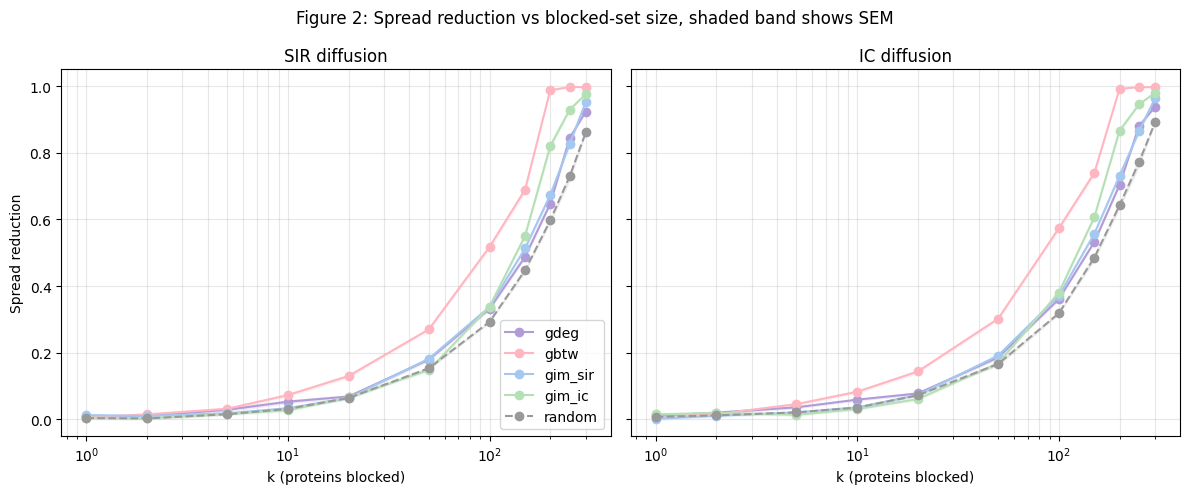

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)
colors = {
    "gdeg": "#B19CD9",
    "gbtw": "#FFB6C1",
    "gim_sir": "#A4C8F0",
    "gim_ic": "#B5E0B5",
    "random": "#999999",
}
chain_order = ["gdeg", "gbtw", "gim_sir", "gim_ic", "random"]

for ax, model in zip(axes, ["SIR", "IC"]):
    for name in chain_order:
        linestyle = "--" if name == "random" else "-"
        y = np.array(reductions[model][name])
        sem = np.array(reduction_sems[model][name])
        ax.fill_between(K_VALUES, y - sem, y + sem, color=colors[name], alpha=0.2, linewidth=0)
        ax.plot(K_VALUES, y, color=colors[name], linestyle=linestyle, marker="o", label=name)
    ax.set_xscale("log")
    ax.set_xlabel("k (proteins blocked)")
    ax.set_title(f"{model} diffusion")
    ax.grid(True, which="both", alpha=0.3)
    ax.set_ylim(-0.05, 1.05)

axes[0].set_ylabel("Spread reduction")
axes[0].legend(loc="lower right")
fig.suptitle("Figure 2: Spread reduction vs blocked-set size, shaded band shows SEM")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "fig2_spread_reduction.pdf", bbox_inches="tight")
plt.show()


## Main experiment results

Figure 2 shows that the four strategies separate clearly under both SIR and IC propagation, with `gbtw` dominating throughout.

`gbtw` is the only chain that produces a clean plateau. At k=200 under SIR it reaches 98.7% reduction, climbs to 99.7% at k=250, and is flat thereafter; under IC, 99.1% at k=200 and 99.7% at k=250. The other chains continue climbing through k=300, but past k around 200 their gains come from the shrinking graph rather than from informed blocking: at k=300 even the random baseline reaches 86% reduction under SIR and 89% under IC simply because two thirds of the network is removed. The meaningful comparison is therefore at k less than or equal to 200, where `gbtw`'s gap over the next-best strategy is 12 to 17 percentage points depending on the diffusion model.

The diffusion-aware CELF chains underperform structural betweenness in this regime. CELF_SIR reaches 33.7% reduction at k=100 versus `gbtw` at 51.7%, and the gap widens through k=200. Two effects compound. First, the dense PPI network rewards removing high-betweenness hubs because they sit on many propagation paths simultaneously, so structural betweenness is a good proxy for diffusion-disrupting capacity in this regime. Second, CELF's marginal-gain estimates rely on Monte Carlo simulations with 25 inner replicates, which carry enough noise that the differences between near-equivalent candidates flatten and small ranking errors compound. CELF is the theoretically correct algorithm for spread maximization on submodular objectives, but in dense graphs with noisy simulations it is outperformed by a simpler structural heuristic.

One asymmetry is worth flagging. CELF_IC outperforms CELF_SIR on both diffusion models, reaching 82.0% at k=200 SIR and 86.6% at k=200 IC against CELF_SIR's 67.3% and 73.1%. The chain optimized for the single-shot IC dynamic transfers cleanly to the multi-attempt SIR dynamic, while the reverse is not true. Likely mechanism: IC's percolation-style dynamics give the lazy-greedy ranking sharper marginal gains, producing a stronger and more transferable chain.

The random baseline behaves as expected: lowest spread reduction at every k, slowly climbing toward saturation as blocked nodes accumulate. Every algorithmic chain stays at least a few percentage points above random across all k, confirming that informed selection does help; the question is by how much, and for `gbtw` the answer is substantial.

For the research question, the conclusion is clear. The optimal blocking set depends strongly on the chosen algorithm. Structural greedy iterative betweenness is the dominant strategy on this dense PPI network and saturates with k around 200 proteins blocked, representing 44% of the graph. Diffusion-aware CELF picks different proteins under different simulators, a finding the chain selection already established at the top of the chain, but neither CELF variant matches the structural strategy when measured by spread reduction on this dataset.


## PPI vs null models

A clean conclusion about PPI requires running the same algorithms on the random graphs of comparable size and density. If `gbtw` saturates the same way on ER, BA, and CM, the main-experiment result reflects graph density alone rather than biological structure. If the curves differ, the topology of the endometriosis PPI is doing real work.

Three design choices keep this comparison clean.

First, we run only `gdeg` and `gbtw` on the null graphs. The main experiment showed that `gbtw` dominates and CELF underperforms in dense graphs, so re-running CELF on three more null graphs would add roughly an hour of compute without changing the comparison.

Second, we use a single diffusion model. SIR with the calibrated β = 0.005, γ = 0.20 is sufficient; the main experiment confirmed that IC produces qualitatively identical curves.

Third, we use 23 random seeds drawn uniformly at random in every network including PPI. This isolates graph structure as the only variable that differs across the four runs and removes the confounding effect of biologically meaningful seed selection. The PPI numbers here will therefore differ slightly from the numbers in the main experiment, where `DISEASE_SEEDS` were used.

The figure plots spread reduction versus k. The left panel shows `gdeg`, the right panel shows `gbtw`; in each panel, one curve per network using the Figure 1 color palette.

In [15]:
n_seeds = len(DISEASE_SEEDS)
seed_rng = np.random.default_rng(RANDOM_SEED)

network_seeds = {
    name: list(seed_rng.choice(list(G.nodes), size=n_seeds, replace=False))
    for name, G in networks.items()
}

null_chains = {}
null_reductions = {}
null_reduction_sems = {}
for name, G in networks.items():
    seeds = network_seeds[name]
    print(f"\n{name}: building chains and evaluating...")
    if name == "PPI":
        gdeg_chain = chain_gdeg
        gbtw_chain = chain_gbtw
    else:
        gdeg_chain = greedy_group_degree(G, K_MAX)
        gbtw_chain = greedy_iterative_betweenness(G, K_MAX)
    null_chains[name] = {"gdeg": gdeg_chain, "gbtw": gbtw_chain}

    baseline, _ = simulate_sir(G, seeds, beta=SIR_BETA, gamma=SIR_GAMMA)
    g_pairs = [simulate_sir(G, seeds, blocked=gdeg_chain[:k], beta=SIR_BETA, gamma=SIR_GAMMA) for k in K_VALUES]
    b_pairs = [simulate_sir(G, seeds, blocked=gbtw_chain[:k], beta=SIR_BETA, gamma=SIR_GAMMA) for k in K_VALUES]
    red_g = [1 - m / baseline for m, _ in g_pairs]
    red_b = [1 - m / baseline for m, _ in b_pairs]
    sem_g = [s / np.sqrt(N_RUNS) / baseline for _, s in g_pairs]
    sem_b = [s / np.sqrt(N_RUNS) / baseline for _, s in b_pairs]
    null_reductions[name] = {"gdeg": red_g, "gbtw": red_b, "baseline": baseline}
    null_reduction_sems[name] = {"gdeg": sem_g, "gbtw": sem_b}
    idx_200 = K_VALUES.index(200)
    print(f"  baseline = {baseline:.1f},  gdeg@k=200 = {red_g[idx_200]:.3f},  gbtw@k=200 = {red_b[idx_200]:.3f}")



PPI: building chains and evaluating...


  baseline = 325.0,  gdeg@k=200 = 0.666,  gbtw@k=200 = 0.880

ER: building chains and evaluating...


  baseline = 394.3,  gdeg@k=200 = 0.685,  gbtw@k=200 = 0.823

BA: building chains and evaluating...


  baseline = 377.4,  gdeg@k=200 = 0.892,  gbtw@k=200 = 0.914

CM: building chains and evaluating...


  baseline = 335.9,  gdeg@k=200 = 0.681,  gbtw@k=200 = 0.958


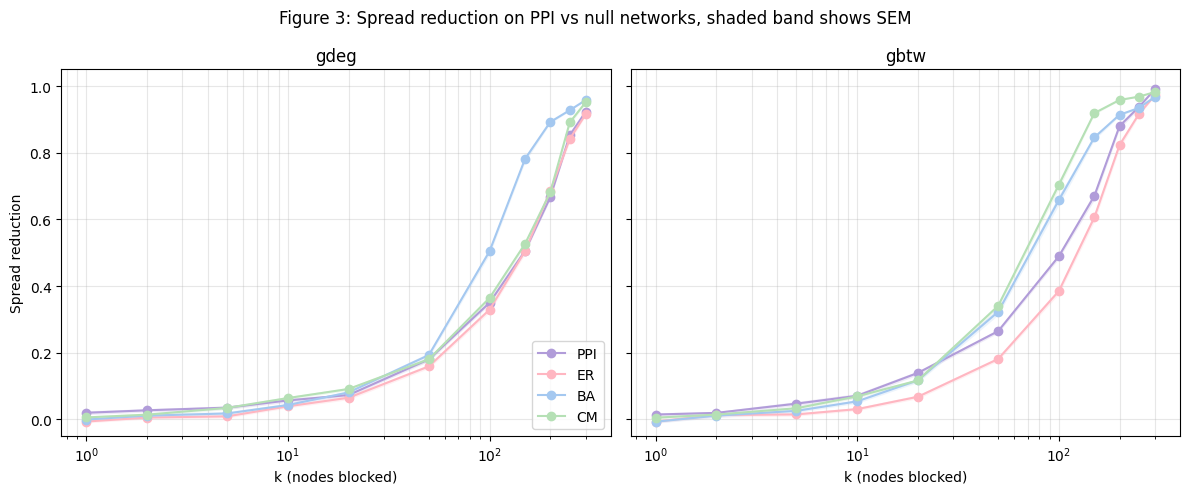

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)
network_colors = {"PPI": "#B19CD9", "ER": "#FFB6C1", "BA": "#A4C8F0", "CM": "#B5E0B5"}

for ax, algo in zip(axes, ["gdeg", "gbtw"]):
    for name in ["PPI", "ER", "BA", "CM"]:
        y = np.array(null_reductions[name][algo])
        sem = np.array(null_reduction_sems[name][algo])
        ax.fill_between(K_VALUES, y - sem, y + sem, color=network_colors[name], alpha=0.2, linewidth=0)
        ax.plot(K_VALUES, y, color=network_colors[name], marker="o", label=name)
    ax.set_xscale("log")
    ax.set_xlabel("k (nodes blocked)")
    ax.set_title(algo)
    ax.grid(True, which="both", alpha=0.3)
    ax.set_ylim(-0.05, 1.05)

axes[0].set_ylabel("Spread reduction")
axes[0].legend(loc="lower right")
fig.suptitle("Figure 3: Spread reduction on PPI vs null networks, shaded band shows SEM")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "fig3_ppi_vs_nulls.pdf", bbox_inches="tight")
plt.show()


## PPI vs null models results

Figure 3 shows that PPI differs from all three null models, and the differences track the structural distinctions established by the network statistics.

The cleanest comparison is PPI versus CM under `gbtw`. CM at k=200 reaches 95.8% spread reduction while PPI reaches only 88.0%. Both networks share the same degree sequence by construction, so the 7.8 percentage point gap is attributable entirely to higher-order structure: clustering and positive assortativity. PPI is more resistant to betweenness-based attack than its degree-randomized version, which means the modular organization of biological interactions adds robustness beyond what degrees alone explain.

Under `gdeg`, PPI is the most resistant network at k=200, at 66.6% reduction compared to ER at 68.5%, CM at 68.1%, and BA at 89.2%. PPI's clustering embeds high-degree proteins inside cohesive modules rather than at articulation points; removing them fragments the network less efficiently than in either random or scale-free baselines.

BA is uniquely vulnerable to `gdeg`, reaching 89.2% reduction at k=200. Its scale-free degree distribution places almost all connectivity on a handful of extreme hubs whose removal fragments the network rapidly. PPI does not show this signature; despite having a heavy-tailed degree distribution, its hubs are buffered by the cluster structure that the degree distribution alone does not capture.

The unblocked baselines also order consistently. PPI at 325 and CM at 336 propagate the signal less far than ER at 394 or BA at 377. PPI and CM already restrict spread through degree and topological constraints; ER and BA, which are more uniformly or hub-centrically connected, propagate further before any blocking begins.

The cleanest result is structural. PPI and the configuration null share the same degree sequence by construction, yet PPI resists `gbtw` attack by 7.8 percentage points more. The gap must come from higher-order topology, specifically clustering and positive assortativity. Under `gbtw`, ER is marginally more resistant than PPI by 5.7 percentage points, because the diffuse Erdős-Rényi topology lacks structural targets to attack at all; this is a feature of the null, not a defect of the PPI finding. Under `gdeg`, PPI is the most resistant of the four networks. From a drug-targeting perspective the cautionary finding stands: even ideal selection algorithms face structural redundancy from clustering that protects pathway integrity against partial interventions.


## Top-k composition analysis

The chain-selection overlap counts told us how many proteins the chains share at fixed depths, but not which proteins those are or how the rankings differ. Figure 4 visualizes the union of the top-20 picks across the four chains as a rank heatmap: rows are proteins, columns are algorithms, each cell shows the rank if the protein appears in that chain's top-20 and is blank otherwise. Proteins are sorted top to bottom by the number of chains that include them, then by mean rank within those chains, so consensus picks rise to the top and algorithm-specific picks fall to the bottom.

The figure is informative in two ways. First, it identifies the proteins that every strategy converges on regardless of dynamics or objective; those are the natural high-confidence candidates for any intervention designed around this PPI. Second, it surfaces the algorithm-specific picks, revealing what each algorithm sees that the others miss, which matters both for the report's biological interpretation and for any future use of these selection methods.

In [17]:
TOP_K = 20

chain_names = list(chains.keys())

top_picks = {name: chain[:TOP_K] for name, chain in chains.items()}
union = sorted(set().union(*top_picks.values()))

rank_matrix = {
    p: {n: (chains[n].index(p) + 1 if p in top_picks[n] else None) for n in chain_names}
    for p in union
}
agreement = {p: sum(1 for n in chain_names if rank_matrix[p][n] is not None) for p in union}


def sort_key(p):
    ranks = [rank_matrix[p][n] for n in chain_names if rank_matrix[p][n] is not None]
    return (-agreement[p], np.mean(ranks))


sorted_proteins = sorted(union, key=sort_key)

display_proteins = sorted_proteins[:25]
print(f"Top-{TOP_K} union: {len(sorted_proteins)} distinct proteins, "
      f"{sum(1 for p in union if agreement[p] >= 2)} appear in 2 or more chains.\n"
      f"Showing all shared picks and the first 20 algorithm-specific picks; "
      f"the full list of 75 is reflected in Figure 4.\n")
header = f"{'protein':<12s}" + "  ".join(f"{n:>9s}" for n in chain_names) + "  agree"
print(header)
for p in display_proteins:
    cells = "  ".join(
        f"{rank_matrix[p][n] if rank_matrix[p][n] else '-':>9}" for n in chain_names
    )
    print(f"{p:<12s}{cells}  {agreement[p]:>5}")


Top-20 union: 75 distinct proteins, 5 appear in 2 or more chains.
Showing all shared picks and the first 20 algorithm-specific picks; the full list of 75 is reflected in Figure 4.

protein          gdeg       gbtw    gim_sir     gim_ic  agree
ESR1                2          2          -          -      2
IL6                 1          4          -          -      2
EGFR                5          3          -          -      2
INS                 6          8          -          -      2
CYP3A4             10         14          -          -      2
ALB                 -          1          -          -      1
CD40                -          -          -          1      1
FGF4                -          -          1          -      1
KDR                 -          -          2          -      1
LAG3                -          -          -          2      1
AKR1C3              3          -          -          -      1
CX3CL1              -          -          -          3      1
UGT1A7       

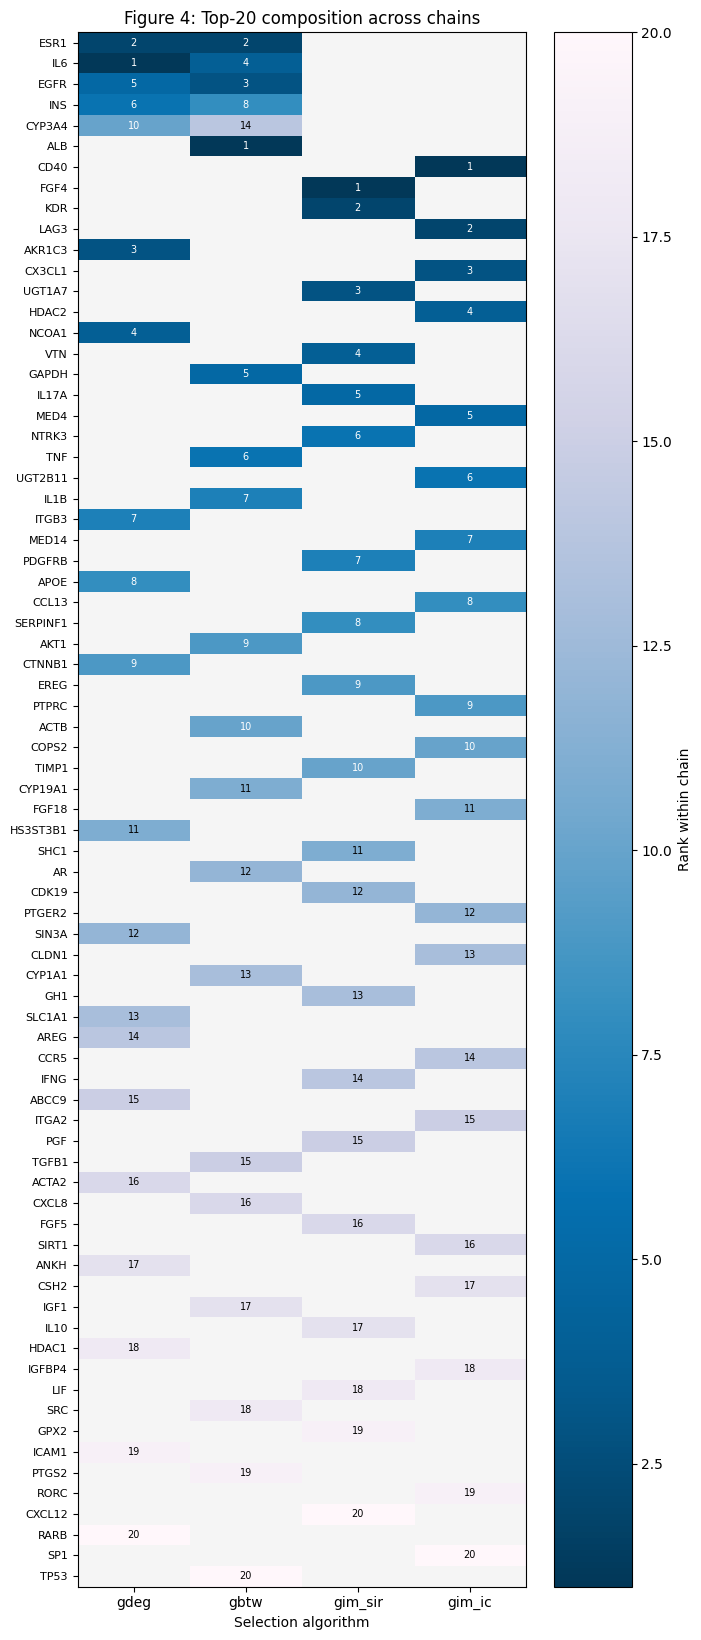

In [18]:
matrix = np.full((len(sorted_proteins), len(chain_names)), np.nan)
for i, p in enumerate(sorted_proteins):
    for j, n in enumerate(chain_names):
        if rank_matrix[p][n] is not None:
            matrix[i, j] = rank_matrix[p][n]

cmap = plt.cm.PuBu_r.copy()
cmap.set_bad(color="#f5f5f5")

fig, ax = plt.subplots(figsize=(7, max(8, len(sorted_proteins) * 0.22)))
im = ax.imshow(matrix, cmap=cmap, vmin=1, vmax=TOP_K, aspect="auto")

for i in range(len(sorted_proteins)):
    for j in range(len(chain_names)):
        if not np.isnan(matrix[i, j]):
            val = int(matrix[i, j])
            text_color = "white" if val <= TOP_K // 2 else "black"
            ax.text(j, i, str(val), ha="center", va="center", fontsize=7, color=text_color)

ax.set_xticks(range(len(chain_names)))
ax.set_xticklabels(chain_names)
ax.set_yticks(range(len(sorted_proteins)))
ax.set_yticklabels(sorted_proteins, fontsize=8)
ax.set_xlabel("Selection algorithm")
ax.set_title(f"Figure 4: Top-{TOP_K} composition across chains")

fig.colorbar(im, ax=ax, label="Rank within chain")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "fig4_topk_composition.pdf", bbox_inches="tight")
plt.show()

## Top-k composition results

Figure 4 confirms that the chains do not converge on a core set. The union of the top-20 picks contains 75 distinct proteins; only 5 appear in two chains, none in three or more. About 93% of the union is algorithm-specific.

A single consensus cluster emerges, and it sits entirely on the structural side. `gdeg` and `gbtw` share ESR1, IL6, EGFR, INS, and CYP3A4. ESR1 is the estrogen receptor and is biologically central to endometriosis as an estrogen-dependent disease; the rest are classic signaling hubs whose centrality in any PPI database is well documented. Two of `gbtw`'s top picks, GAPDH at rank 5 and ACTB at rank 10, are housekeeping genes whose centrality is largely an annotation artifact of PPI databases rather than a biological signal, and they fall out of `gdeg` for that reason.

Every other pairwise comparison among the four chains has zero overlap in the top 20: the two CELF chains share nothing with each other, and neither shares anything with either structural chain. The structural-vs-diffusion divide is therefore absolute at the top of the ranking and only relaxes around rank 100. This is the strongest single piece of evidence for the algorithm-dependence finding.

The diffusion-aware chains select two coherent and biologically meaningful but disjoint functional clusters.

`gim_sir` leads with FGF4, KDR, PDGFRB, EREG and other growth-factor and angiogenesis proteins, complemented by ECM-remodeling targets VTN, SERPINF1, TIMP1 and the inflammation marker IL17A. Angiogenesis and extracellular matrix remodeling are recognized pathological axes in endometriosis lesion development, and these proteins are not picked up by structural centrality because their PPI-database degree is lower than the canonical signaling hubs.

`gim_ic` leads with CD40, LAG3, CX3CL1, CCL13, PTPRC and other immune-modulation proteins, complemented by transcriptional-regulation targets HDAC2, MED4, MED14, COPS2. Immune dysregulation is a second well-documented axis of endometriosis pathology, and the IC dynamic, which propagates in single-shot percolation rather than persistent multi-attempt contagion, surfaces signaling intermediaries that the SIR-trained chain does not.

The figure visually answers the second half of the research question: optimal-blocking-set composition is strongly algorithm-dependent. A practitioner choosing an intervention strategy would receive materially different recommendations from each algorithm, and CELF under different propagation models produces non-overlapping biological narratives. The divergence is informative rather than problematic: it tells the practitioner which biological functions each algorithm is sensitive to and lets the choice of algorithm reflect prior biological knowledge about the disease.


## Final conclusion

This project asked which set of k proteins, blocked simultaneously, most effectively limits propagation of the disease signal in the endometriosis PPI network, and whether the optimal set depends on the chosen measure.

The network statistics established that the empirical PPI differs from all three null models in two structurally meaningful ways: clustering is 0.637 in PPI against 0.512 in the degree-matched configuration null, and assortativity is positive at 0.052 against negative or near-zero values in every random model.

Calibration set SIR at beta = 0.005, gamma = 0.20 and IC at p = 0.02 to operate at roughly 70% and 65% spread on the unblocked PPI graph. Seeds were restricted to the top-quartile DisGeNET disease genes, giving a 5% seed floor.

Chain selection produced four ordered blocking chains using three group centrality algorithms: greedy group degree, greedy iterative betweenness, and CELF run twice under SIR and IC respectively. The two CELF chains share zero proteins with each other in their top 10, and zero with either structural chain, foreshadowing the algorithm-dependence finding.

The main experiment evaluated each chain at every k under both diffusion models, with a random baseline as control. Greedy iterative betweenness dominated, reaching 98.7% spread reduction at k=200 under SIR and 99.1% under IC, and saturating thereafter. CELF underperformed in this regime; the dense PPI rewards removing high-betweenness hubs because they sit on many propagation paths simultaneously, and CELF's marginal-gain estimates carry enough Monte Carlo noise to flatten the differences between near-equivalent candidates.

The null-model comparison confirmed that the `gbtw` result reflects PPI-specific structure. Under `gbtw`, the configuration null reaches 95.8% reduction at k=200 against PPI's 88.0%, a 7.8 percentage point gap attributable entirely to higher-order structure since both networks share the same degree sequence.

The top-k composition analysis showed that the top-20 union across chains contains 75 distinct proteins, only 5 of which appear in two chains and none in three or more. The five shared picks are all structural-vs-structural agreements, namely ESR1, IL6, EGFR, INS, and CYP3A4; every diffusion-vs-structural and diffusion-vs-diffusion comparison has zero top-20 overlap. CELF surfaces biologically meaningful endometriosis-relevant targets that pure topology misses entirely: angiogenesis and ECM-remodeling proteins such as FGF4, KDR, PDGFRB, VTN, and TIMP1 under SIR, and immune-modulation proteins such as CD40, LAG3, CX3CL1, and CCL13 under IC.

The direct answer to the research question is twofold. The optimal blocking set of size k is the prefix of the greedy iterative betweenness chain, which saturates around k = 200, representing 44% of the graph. The optimal set depends strongly on the chosen measure: about 93% of top-20 picks are algorithm-specific, the two CELF chains share zero proteins in their top-10, and the structural and diffusion-aware strategies also share zero proteins in their top-10.

The practical takeaway is that partial blocking is a limited intervention strategy on this network. Substantial signal reduction requires removing roughly 200 of 454 proteins, far beyond what any realistic pharmacological intervention can target; at k = 10 even the best algorithm achieves only 7 percent reduction under SIR. The PPI's clustering and modular structure buffer signaling against the removal of a small number of proteins, a property the null-model comparison confirms is specific to the topology rather than an artifact of the diffusion model. The biologically valuable output of the analysis is therefore not the spread-reduction number itself but the candidate protein lists: diffusion-aware algorithms surface angiogenesis, ECM-remodeling, and immune-modulation targets that align with known endometriosis pathology and merit investigation in their own right.

Several limitations qualify these conclusions. CELF used 25 inner Monte Carlo replicates per inference instead of 50; chains may shift if a sensitivity check at 50 were performed. CELF was not re-run on the three null networks, so the null-model comparison covers only the structural algorithms. The disease-seed cutoff of score >= 0.7 was fixed; results may shift at a different threshold. The STRING confidence threshold of 0.4 produces a dense graph that favors structural attacks; a stricter threshold would change the regime. Diffusion parameters were calibrated at one operating point only, with no sensitivity sweep on beta, gamma, or p.

Three broader implications emerge. First, real protein interaction networks have evolved structural redundancy that limits the impact of partial blocking interventions; small k achieves little reduction even with the best algorithm. Second, the choice of selection algorithm shapes the recommended protein set as strongly as the underlying biology does, so any practical intervention strategy must commit to an algorithm explicitly and justify the choice. Third, diffusion-aware optimization remains valuable even when it does not win on the spread-reduction metric, because it surfaces angiogenesis, ECM-remodeling, and immune-modulation targets that biological intuition would endorse but structural heuristics would miss.
